### In this notebook, we create three catalogs for the AAU stream:
1. The standard candles catalog (small) - Elements from (Delve DR3 Y6 Gold $\cap$ Gaia DR3) $\cup$ Gaia RRLs; assumption from $S^5$ about $\phi_2$ track and proper motion track
2. The photometric + astrometric members catalog (big) - Elements from (DELVE DR3 Y6 Gold $\cap$ Gaia DR3); assumption from $S^5$ about $\phi_2$ track and proper motion track; assumption from Catalog 1. about distance track
3. The photometric members catalog (biggest) - Elements from DELVE DR3 Y6 Gold; assumption from $S^5$ about $\phi_2$ track; assumption from Catalog 1. about distance track

In [42]:
import numpy as np
import pandas as pd
import healpy as hp
import dask
import hats
import lsdb
import astropy
from astropy.coordinates import SkyCoord
from astropy.table import Table
from astropy import units as u
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
from ugali.analysis.isochrone import factory as isochrone_factory
import os
import logging
import time
import sys
code_path = "/astro/users/esb30/software/spreading_seas/code"
sys.path.append(code_path)
from rotation_matrix import phi12_rotmat, pmphi12
from gaussian_membership_fits import quad_f, pm_gaussian_2d, phi2_gaussian, p_photometric
atlas_rotmat = [[0.83697865, 0.29481904, -0.4610298], [0.51616778, -0.70514011, 0.4861566], [0.18176238, 0.64487142, 0.74236331]]

### 1. Read datasets to pull from. Superfluous columns, such as I and Z band magnitudes, may be dropped in exchange for speed.

In [8]:
'''New columns may be added as well:'''
# delve_info = lsdb.read_hats('/epyc/data/delve/dr3/delve_dr3_gold/delve_dr3_gold/')
# print(delve_info.columns.tolist())

'New columns may be added as well:'

In [9]:
delve_object = lsdb.read_hats('/epyc/data/delve/dr3/delve_dr3_gold/delve_dr3_gold/', columns=['COADD_OBJECT_ID', 'RA', 'DEC', 'PSF_MAG_APER_8_G_CORRECTED', 'PSF_MAG_APER_8_R_CORRECTED', 'PSF_MAG_APER_8_I_CORRECTED', 'PSF_MAG_APER_8_Z_CORRECTED', 'EXT_XGB', 'SOURCE', 'PSF_MAG_ERR_APER_8_G', 'PSF_MAG_ERR_APER_8_R'])
lazy_delve = delve_object.query("PSF_MAG_APER_8_G_CORRECTED > 16 and PSF_MAG_APER_8_G_CORRECTED < 24.5 and PSF_MAG_APER_8_G_CORRECTED - PSF_MAG_APER_8_R_CORRECTED > -0.3 and PSF_MAG_APER_8_G_CORRECTED - PSF_MAG_APER_8_R_CORRECTED < 1 and EXT_XGB == 0")
gaia_object = lsdb.read_hats('/epyc/data3/hats/catalogs/gaia_dr3/gaia/', columns=["ra", "dec", "pm", "pmra", "pmdec", "pmra_error", "pmdec_error", "phot_g_mean_mag", "phot_bp_mean_mag", "phot_rp_mean_mag", "pmra_pmdec_corr"])
lazy_gaia = gaia_object.query("phot_g_mean_mag > 16 and phot_g_mean_mag < 24.5")

In [10]:
# time-intensive step 1
print('Computing DELVE DR3')
delve = lazy_delve.compute()
print('Computing Gaia DR3')
gaia = lazy_gaia.compute()

Computing DELVE DR3
Computing Gaia DR3


In [14]:
# time-intensive step 2
delve['phi1'], delve['phi2'] = phi12_rotmat(alpha=delve['RA'].to_numpy(),delta=delve['DEC'].to_numpy(),R_phi12_radec=atlas_rotmat)
gaia['phi1'], gaia['phi2'] = phi12_rotmat(alpha=gaia['ra'].to_numpy(),delta=gaia['dec'].to_numpy(),R_phi12_radec=atlas_rotmat)
delve = delve[(delve['phi1'] > -30) & (delve['phi1'] < 30) & (delve['phi2'] > -6) & (delve['phi2'] < 6)]
gaia = gaia[(gaia['phi1'] > -30) & (gaia['phi1'] < 30) & (gaia['phi2'] > -6) & (gaia['phi2'] < 6)]

print('Crossmatching Data')

delve_coords = SkyCoord(ra=delve['RA'].to_numpy() * u.deg, dec=delve['DEC'].to_numpy() * u.deg)
gaia_coords = SkyCoord(ra=gaia['ra'].to_numpy() * u.deg, dec=gaia['dec'].to_numpy() * u.deg)
idx, angular_separation, _ = delve_coords.match_to_catalog_sky(gaia_coords)
match_radius = 1.0 * u.arcsec
match_mask = angular_separation < match_radius

Crossmatching Data


In [15]:
dxg = pd.DataFrame({
    'coadd_object_id': delve['COADD_OBJECT_ID'],
    'ra': delve['RA'],
    'dec': delve['DEC'],
    'phi1': delve['phi1'],
    'phi2': delve['phi2'],
    'g_mag': delve['PSF_MAG_APER_8_G_CORRECTED'],
    'r_mag': delve['PSF_MAG_APER_8_R_CORRECTED'],
    'i_mag': delve['PSF_MAG_APER_8_I_CORRECTED'],
    'z_mag': delve['PSF_MAG_APER_8_Z_CORRECTED'],
    'e_g_mag': delve['PSF_MAG_ERR_APER_8_G'],
    'e_r_mag': delve['PSF_MAG_ERR_APER_8_R'],
    'gaia_g': np.nan,
    'gaia_bp': np.nan,
    'gaia_rp': np.nan,
    'gaia': match_mask,
    'pmra': np.nan,
    'pmdec': np.nan,
    'pmra_error': np.nan,
    'pmdec_error': np.nan,
    'pmra_pmdec_corr': np.nan
})

gaia_matched = gaia.iloc[idx[match_mask]].reset_index(drop=True)

dxg.loc[match_mask, 'pmra'] = gaia_matched['pmra'].values
dxg.loc[match_mask, 'pmdec'] = gaia_matched['pmdec'].values
dxg.loc[match_mask, 'pmra_error'] = gaia_matched['pmra_error'].values
dxg.loc[match_mask, 'pmdec_error'] = gaia_matched['pmdec_error'].values
dxg.loc[match_mask, 'gaia_g'] = gaia_matched['phot_g_mean_mag'].values
dxg.loc[match_mask, 'gaia_bp'] = gaia_matched['phot_bp_mean_mag'].values
dxg.loc[match_mask, 'gaia_rp'] = gaia_matched['phot_rp_mean_mag'].values
dxg.loc[match_mask, 'pmra_pmdec_corr'] = gaia_matched['pmra_pmdec_corr'].values

dxg['pmphi1'], dxg['pmphi2'] = pmphi12(alpha=dxg['ra'],delta=dxg['dec'],mu_alpha_cos_delta=dxg['pmra'],mu_delta=dxg['pmdec'],R_phi12_radec=atlas_rotmat)

dxg_on = dxg[(dxg['phi1'] > -30) &(dxg['phi2'] < 6) &(dxg['phi2'] > -6) & (dxg['phi1'] < 30)] # Use the aau filter on 'dxg_on' for pmra vs pmdec plot -5 to 5

/tmp/ipykernel_3183819/1139575954.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<ArrowExtensionArray>
[-0.6977157759173633,  1.2460183828843825,  0.6029918483802713,
   4.987894363457104, -0.1153386621941676,                <NA>,
 -1.9567413069612491,   87.43092951337927, -0.2990376937969734,
   2.446543157560804,
 ...
  3.8212715701453455,   6.587030095836493,   2.532546984245749,
   24.16190928942004,   12.50311738131326,  0.6247129862558848,
   7.094276029144767,   9.514354854158988,                <NA>,
 -0.1989410405082946]
Length: 674454, dtype: double[pyarrow]' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  dxg.loc[match_mask, 'pmra'] = gaia_matched['pmra'].values
/tmp/ipykernel_3183819/1139575954.py:27: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<ArrowExtensionA

In [16]:
# load Gaia RRL catalog. Revisit this to make sure we're taking our RRL data from the correct place.
gaia_rrl_catalog = pd.read_parquet('/epyc/data/gaia_rrl/li_xmatch.parq')

### 2.  Create standard candles catalog

In [23]:
bhb = dxg_on[
    (dxg_on['g_mag'] - dxg_on['r_mag'] > -0.3) & 
    (dxg_on['g_mag'] - dxg_on['r_mag'] < 0) & 
    (dxg_on['g_mag'] - 16.66 > -1) & # assume central distance value = 16.66
    (dxg_on['g_mag'] - 16.66 < 2) # BHB gmags usually range from 0 to 1, and I am allowing a distance gradient of +/- 1 on each side
]

In [24]:
gaia_rrl_catalog = gaia_rrl_catalog.rename(columns={'Gaia_gaia_rrl_w_dist': 'source_id', 'ra_gaia_rrl_w_dist': 'ra', 'dec_gaia_rrl_w_dist':'dec', 'Dist_Phot_gaia_rrl_w_dist':'dist', 'e_Dist_Phot_gaia_rrl_w_dist':'e_dist', 'pmra_gaia':'pmra', 'pmra_error_gaia':'e_pmra', 'pmdec_gaia':'pmdec', 'pmdec_error_gaia':'e_pmdec'})
gaia_rrl_catalog['phi1'], gaia_rrl_catalog['phi2'] = phi12_rotmat(alpha=gaia_rrl_catalog['ra'],delta=gaia_rrl_catalog['dec'],R_phi12_radec=atlas_rotmat)
rrl = gaia_rrl_catalog[(gaia_rrl_catalog['phi1'] > -30) & (gaia_rrl_catalog['phi1'] < 30) & (gaia_rrl_catalog['phi2'] > -6) & (gaia_rrl_catalog['phi2'] < 6)]

Below, the stream = 'AAU' parameter bakes in assumptions about the pmra and pmdec tracks.

In [25]:
rrl['p_spatial'] = phi2_gaussian(phi2=rrl['phi2'], phi1=rrl['phi1'])
rrl['p_pm'] = pm_gaussian_2d(pmra=rrl['pmra'], pmdec=rrl['pmdec'], phi1=rrl['phi1'], pmra_error=rrl['e_pmra'], pmdec_error=rrl['e_pmdec'], stream='AAU')
bhb['p_spatial'] = phi2_gaussian(phi2=bhb['phi2'], phi1=bhb['phi1'])
bhb['p_pm'] = pm_gaussian_2d(pmra=bhb['pmra'], pmdec=bhb['pmdec'], phi1=bhb['phi1'], pmra_error=bhb['pmra_error'], pmdec_error=bhb['pmdec_error'], stream='AAU')

In [26]:
bhb['g_r'] = bhb['g_mag'] - bhb['r_mag']
def bhb_absolute_mag(g_r): # BHB absolute magnitude relation from Barbosa et al 2022 https://arxiv.org/pdf/2210.02820
    return 0.398 - 0.392 * (g_r) + 2.729 * (g_r)**2 + 29.1128 * (g_r)**3 + 113.569 * (g_r)**4
bhb['M_g'] = bhb_absolute_mag(bhb['g_r'])
bhb['distance_modulus'] = bhb['g_mag'] - bhb['M_g']

rrl['distance_modulus'] = (rrl['phot_g_mean_mag_gaia']-rrl['MGmag_gaia_rrl_w_dist'])

In [28]:
rrl_subset = pd.DataFrame({
    'ra': rrl['ra'],
    'dec': rrl['dec'],
    'phi1': rrl['phi1'],
    'phi2': rrl['phi2'],
    'distance_modulus': rrl['distance_modulus'],
    'pmra': rrl['pmra'],
    'pmdec': rrl['pmdec'],
    'p_pm': rrl['p_pm'],
    'p_spatial': rrl['p_spatial'],
    'gaia_g': rrl['MGmag_gaia_rrl_w_dist'],
    'gaia_bp': rrl['phot_bp_mean_mag_gaia'],
    'gaia_rp': rrl['phot_rp_mean_mag_gaia'],
    'delve_g': np.nan,
    'delve_r': np.nan,
    'rrl?': True,
    'bhb?': False
})

bhb_subset = pd.DataFrame({
    'ra': bhb['ra'],
    'dec': bhb['dec'],
    'phi1': bhb['phi1'],
    'phi2': bhb['phi2'],
    'distance_modulus': bhb['distance_modulus'],
    'pmra': bhb['pmra'],
    'pmdec': bhb['pmdec'],
    'p_pm': bhb['p_pm'],
    'p_spatial': bhb['p_spatial'],
    'gaia_g': bhb['gaia_g'],
    'gaia_bp': bhb['gaia_bp'],
    'gaia_rp': bhb['gaia_rp'],
    'delve_g': bhb['g_mag'],
    'delve_r': bhb['r_mag'],
    'rrl?': False,
    'bhb?': True
})

bhb_rrl= pd.concat([rrl_subset, bhb_subset], ignore_index=True)

In [35]:
good_mask = (bhb_rrl['p_pm'] * bhb_rrl['p_spatial'] > 0.1) & (bhb_rrl['distance_modulus'] < 18.75) # 18.75 is empirically and visually derived
rrl_mask = bhb_rrl['rrl?']
bhb_mask = bhb_rrl['bhb?']
# potentially add a line here to fail RRLs that are identified as BHBs. Do this after evaluating which RRL catalog to use.
print(f'Number of passes: {len(bhb_rrl[good_mask])}')

Number of passes: 20


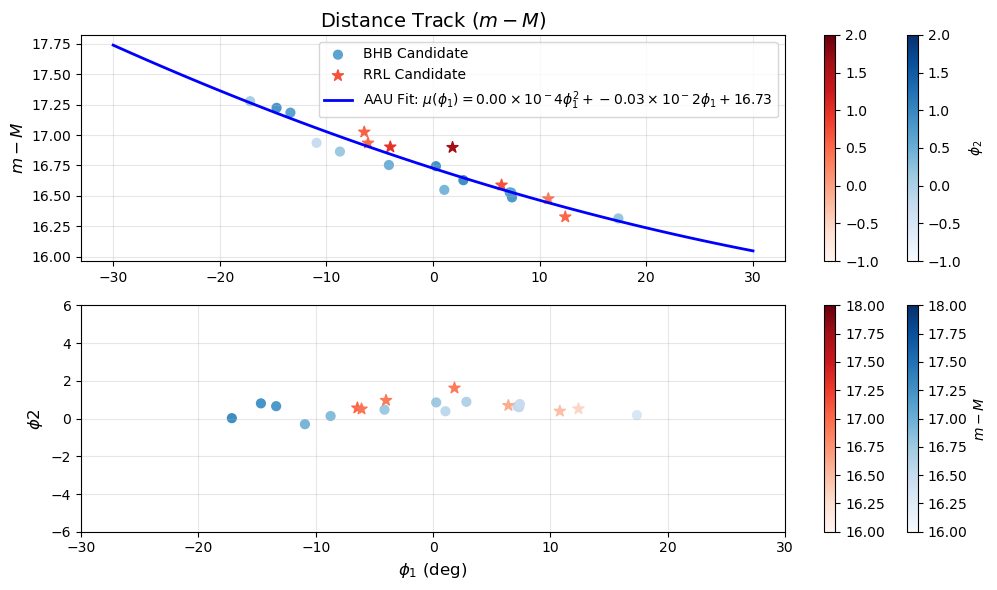

In [33]:
fig,[ax,ax1]=plt.subplots(2,1,figsize=(10, 6))
im1=ax.scatter(
    bhb_rrl[good_mask & bhb_mask]['phi1'],
    bhb_rrl[good_mask & bhb_mask]['distance_modulus'],
    c=bhb_rrl[good_mask & bhb_mask]['phi2'],
    s=40,
    alpha=1,
    vmin=-1,
    vmax=2,
    label='BHB Candidate',
    cmap='Blues'
)

im2=ax.scatter(
    bhb_rrl[good_mask & rrl_mask]['phi1'],
    bhb_rrl[good_mask & rrl_mask]['distance_modulus'],
    c=bhb_rrl[good_mask & rrl_mask]['phi2'],
    s=70,
    alpha=1,
    vmin=-1,
    vmax=2,
    marker='*',
    label='RRL Candidate',
    cmap='Reds'
)

ax.set_ylabel(r'$m - M$', fontsize=12)
ax.set_title(r'Distance Track ($m-M$)', fontsize=14)
ax.grid(alpha=0.3)

phi1 = np.linspace(-30, 30, 100)
coefficients = np.polyfit(bhb_rrl[good_mask]['phi1'], bhb_rrl[good_mask]['distance_modulus'], deg=2)
bhb_fit = np.poly1d(coefficients)
mu = bhb_fit(phi1)
ax.plot(phi1, mu, 'b-', linewidth=2, label=rf'AAU Fit: $\mu(\phi_1) = {coefficients[0]:.2f} \times 10^{-4} \phi_1^2 + {coefficients[1]:.2f} \times 10^{-2} \phi_1 + {coefficients[2]:.2f}$')

fig.colorbar(im1, ax=ax, label=r'$\phi_2$', fraction=0.05)
fig.colorbar(im2, ax=ax, label='', fraction=0.05)
im3=ax1.scatter(
    bhb_rrl[good_mask & bhb_mask]['phi1'],
    bhb_rrl[good_mask & bhb_mask]['phi2'],
    c=bhb_rrl[good_mask & bhb_mask]['distance_modulus'],
    s=40,
    alpha=1,
    vmax=18,
    vmin=16,
    label='BHB Candidate',
    cmap='Blues'
)

im4=ax1.scatter(
    bhb_rrl[good_mask & rrl_mask]['phi1'],
    bhb_rrl[good_mask & rrl_mask]['phi2'],
    c=bhb_rrl[good_mask & rrl_mask]['distance_modulus'],
    s=70,
    alpha=1,
    vmax=18,
    vmin=16,
    marker='*',
    label='RRL Candidate',
    cmap='Reds'
)
ax1.set_xlabel(r'$\phi_1$ (deg)', fontsize=12)
ax1.set_ylabel(r'$\phi2$', fontsize=12)
ax1.grid(alpha=0.3)
ax1.set_xlim(-30,30)
ax1.set_ylim(-6,6)
fig.colorbar(im3, ax=ax1, label=r'$m - M$', fraction=0.05)
fig.colorbar(im4, ax=ax1, label='', fraction=0.05)

ax.legend()
plt.tight_layout()
plt.show()

In [38]:
print('Saving standard candles catalog:')
#bhb_rrl[good_mask].to_parquet('aau_bhb_rrl.parquet', compression="snappy")

Saving standard candles catalog:


### 3. Create photometric + astrometric members catalog

In [52]:
def mu(phi1):
    '''Distance modulus for AAU stream'''
    return 16.727 - 0.0282 * phi1 + 0.00018 * (phi1 ** 2)

In [51]:
dxg_on['p_spatial'] = phi2_gaussian(phi2=dxg_on['phi2'], phi1=dxg_on['phi1'], stream='AAU')

In [78]:
dxg_on['p_photometric'] = p_photometric(mag_g=dxg_on['g_mag'], mag_r=dxg_on['r_mag'], g_err=dxg_on['e_g_mag'], r_err=dxg_on['e_r_mag'], age=12, z=0.0007, mu=mu(dxg_on['phi1']))

In [79]:
dxg_on['p_pm'] = pm_gaussian_2d(pmra=dxg_on['pmra'], pmdec=dxg_on['pmdec'], phi1=dxg_on['phi1'], pmra_error=dxg_on['pmra_error'], pmdec_error=dxg_on['pmdec_error'], pmra_pmdec_corr=dxg_on['pmra_pmdec_corr'], stream='AAU', widen=None, normalize_peak=True)

In [80]:
dxg_on['p_total'] = dxg_on['p_pm'] * dxg_on['p_spatial']* dxg_on['p_photometric']

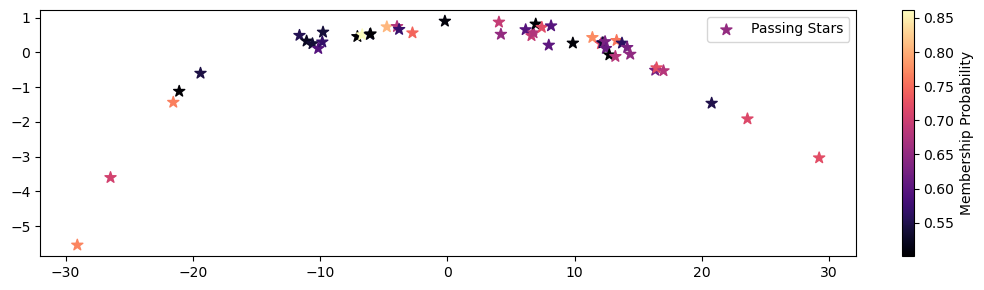

In [85]:
fig,ax = plt.subplots(1,1,figsize=(10, 3))
im=ax.scatter(
    dxg_on[dxg_on['p_total']>0.5]['phi1'],
    dxg_on[dxg_on['p_total']>0.5]['phi2'],
    c=dxg_on[dxg_on['p_total']>0.5]['p_total'],
    s=70,
    alpha=1,
    marker='*',
    label='Passing Stars',
    cmap='magma'
)
ax1.set_xlabel(r'$\phi_1$ (deg)', fontsize=12)
ax1.set_ylabel(r'$\phi2$', fontsize=12)
ax1.grid(alpha=0.3)
ax1.set_xlim(-30,30)
ax1.set_ylim(-6,6)
fig.colorbar(im, ax=ax, label=r'Membership Probability', fraction=0.05)

ax.legend()
plt.tight_layout()
plt.show()

In [84]:
print('Saving photometric + astrometric members catalog:')
#dxg_on.to_parquet('dxg_aau.parquet', compression="snappy")

Saving photometric + astrometric members catalog:


### 4. Create photometric members catalog

In [88]:
delve['p_spatial'] = phi2_gaussian(phi2=delve['phi2'], phi1=delve['phi1'], stream='AAU')

In [89]:
delve['p_photometric'] = p_photometric(mag_g=delve['PSF_MAG_APER_8_G_CORRECTED'], mag_r=delve['PSF_MAG_APER_8_R_CORRECTED'], g_err=delve['PSF_MAG_ERR_APER_8_G'], r_err=delve['PSF_MAG_ERR_APER_8_R'], age=12, z=0.0007, mu=mu(delve['phi1']))

No proper motion likelihood assigned, as there is no astrometric information provided in DELVE. Thus, the cutoff for membership probability is made higher.

In [90]:
delve['p_total'] = delve['p_spatial']* delve['p_photometric']

In [105]:
delve_member = delve['p_total'] > 0.9

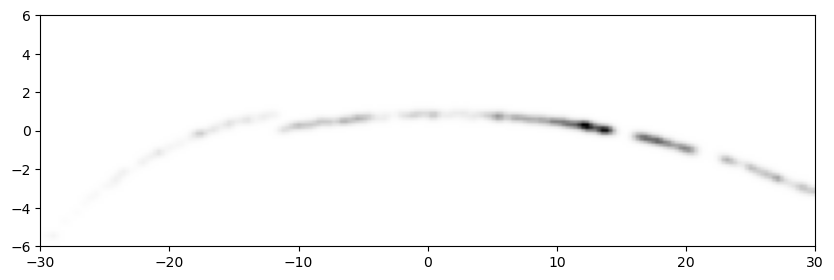

In [106]:
fig, ax = plt.subplots(1,1,figsize=(10,3))
bins_x = np.linspace(-30, 30, 200)
bins_y = np.linspace(-6, 6, 80)
H1, xedges, yedges = np.histogram2d(delve[delve_member]['phi1'], delve[delve_member]['phi2'], bins=[bins_x, bins_y])
smoothed_H1 = gaussian_filter(H1.T, sigma=1)
hist= ax.imshow(
    smoothed_H1,
    extent=[bins_x[0], bins_x[-1], bins_y[0], bins_y[-1]],
    origin='lower',
    cmap='Grays',
    aspect='auto',
#    vmin=0,
#    vmax=150,
)

In [108]:
print('Saving photometric members catalog:')
#delve.to_parquet('delve.parquet', compression="snappy")

Saving photometric members catalog:
